# Project 2: Numerical Methods for PDEs
**Eric Del Toro**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Introduction

In this investigation of finite-difference methods for solving partial differential equations we observe two types: elliptic and parabolic. In Problem A the Laplace equation is solved with a five-point finite-difference discretization with the Gauss-Seidel and SOR methods. In Problem B, Forward Difference, Backward Difference, and Crank-Nicolson methods are used for the one-dimensional heat equation. Comparisons of performance of the respective methods are made with the exact solutions to observe convergence through various conditions. 

By comparing these methods, visualizing their performance, and performing mesh refinement and stability studies, we may observe reflections of their theoretical properties in our computations. 

## Problem A: Elliptic PDE, Laplace Equation

$$u_{xx} + u_{yy} = 0, 0 < x < 1, 0< y< 1$$.
$$u(0,y) = 0, u(x,0) = 0$$,
$$u(x,1) = 100x, u(1,y) = 100y$$.

Given the Laplace equation, we approximate via centered finite differences as follows:

$u_{xx}(x_i, y_i) \approx \frac{w_{i+1,j} - 2w_{i,j} + w_{i-1,j}}{h^2}$,

$u_{yy}(x_i, y_i) \approx \frac{w_{i+1,j} - 2w_{i,j} + w_{i,j-1}}{h^2}$.

Substituting these we get:

$\frac{w_{i+1,j} - 2w_{i,j} + w_{i-1,j}}{h^2} + \frac{w_{i+1,j} - 2w_{i,j} + w_{i,j-1}}{h^2} = 0$.

Multiply both sides by $h^2$ returns:

$w_{i+1,j}-2w_{i,j}+w_{i-1,j} + w_{i,j+1} - 2w_{i,j} + w_{i,j-1} = 0 $.

Combining like terms we get:

$4w_{i,j} - w_{i+1,j} - w_{i-1,j} - w_{i,j+1} - w_{i,j-1} = 0$.

In [3]:
def setup_laplace_grid(h):
    n = int(1 / h) 
    x = np.linspace(0, 1, n + 1)
    y = np.linspace(0, 1, n + 1)
    U = np.zeros((n + 1, n + 1))
    
    # boundary conditions
    for i in range(n + 1):
        U[i, 0] = 0           
        U[i, n] = 100 * x[i]    
    for j in range(n + 1):
        U[0, j] = 0              
        U[n, j] = 100 * y[j]   
    
    return x, y, U

In [4]:
def exact_laplace(x,y):
    return 100*x*y

**Gauss-Seidel**

Having applied the five-point approximation at each mesh point, Gauss-Seidel sequentially solves the resulting system of equations, making immediately updates of recently attained values for unknowns. The process repeats until the difference between iterations falls below the set tolerance. This is the method that will be utilized to solve the resulting linear system of the five-point finite-difference approximation.
$$ w_{i,j}^{(k+1)} = \frac{1}{4}(w_{i+1,j}^{(k)}+w_{i-1,j}^{(k+1)}+w_{i,j+1}^{(k)}+w_{i,j-1}^{(k+1)}). $$

In [5]:
def gauss_seidel_laplace(h, tolerance=1e-6, max_iterations=10000):
    x, y, U = setup_laplace_grid(h)
    n = int(1 / h)
    
    for iteration in range(max_iterations):
        max_change = 0    
        for i in range(1, n):
            for j in range(1, n):
                old = U[i, j]
                U[i, j] = 0.25 * (
                    U[i+1, j] + U[i-1, j] + U[i, j+1] + U[i, j-1]
                )
                
                change = abs(U[i, j] - old)
                if change > max_change:
                    max_change = change        
        if max_change < tolerance:
            return x, y, U, iteration + 1, max_change
    
    return x, y, U, max_iterations, max_change

**Successive Over-Relaxation (SOR)**

The SOR iterative method is a variant of the Gauss-Seidel method which utilizes $\omega$, the relaxation factor, to conduct weighted averages of the previous and newest iterations. This works generally to accelerate the convergence of the Gauss-Seidel method $(1<\omega<2)$, or also to subdue oscillations/prevent divergence in unstable problems $(0<\omega<1)$.
$$w_{i,j}^{(k+1)} = (1-\omega)w_{i,j}^{(k)}+\frac{\omega}{4}(w_{i+1,j}^{(k)}+w_{i-1,j}^{(k+1)}+w_{i,j+1}^{(k)}+w_{i,j-1}^{(k+1)}).$$

In [6]:
def sor_laplace(h, omega=1.5, tolerance=1e-6, max_iterations=10000):
    x, y, U = setup_laplace_grid(h)
    n = int(1 / h)
    for iteration in range(max_iterations):
        max_change = 0
        for i in range(1, n):
            for j in range(1, n):
                old = U[i, j]
                gs = 0.25 * (
                    U[i+1, j] + U[i-1, j] + U[i, j+1] + U[i, j-1]
                )
                U[i, j] = (1 - omega) * old + omega * gs
                
                change = abs(U[i, j] - old)
                if change > max_change:
                    max_change = change    
        if max_change < tolerance:
            return x, y, U, iteration + 1, max_change
    
    return x, y, U, max_iterations, max_change


#### Mesh Point Approximations + Table (Gauss-Seidel)

In [7]:
h = 1/8

x, y, U_num, iterations, final_change = gauss_seidel_laplace(h)

print(f"{'x':<10}{'y':<10}{'Exact':<15}{'Numerical':<15}{'Abs Error':<15}")
print("-"*65)

for i in [2,4,6]:
    for j in [2,4,6]:

        exact_value = exact_laplace(x[i], y[j])

        numerical_value = U_num[i,j]

        error = abs(exact_value - numerical_value)

        print(
            f"{x[i]:<10.3f}"
            f"{y[j]:<10.3f}"
            f"{exact_value:<15.6f}"
            f"{numerical_value:<15.6f}"
            f"{error:<15.6e}"
        )

x         y         Exact          Numerical      Abs Error      
-----------------------------------------------------------------
0.250     0.250     6.250000       6.249996       3.683910e-06   
0.250     0.500     12.500000      12.499996      4.446873e-06   
0.250     0.750     18.750000      18.749997      2.683925e-06   
0.500     0.250     12.500000      12.499996      4.446873e-06   
0.500     0.500     25.000000      24.999995      5.367851e-06   
0.500     0.750     37.500000      37.499997      3.239785e-06   
0.750     0.250     18.750000      18.749997      2.683925e-06   
0.750     0.500     37.500000      37.499997      3.239785e-06   
0.750     0.750     56.250000      56.249998      1.955383e-06   


#### Heat Map (Numerical Solution, Gauss-Seidel)

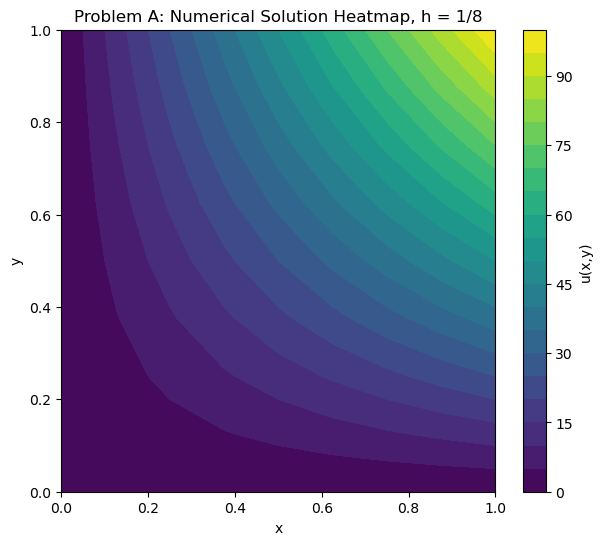

In [8]:
h = 1/8

x, y, U_num, iterations, final_change = gauss_seidel_laplace(h)

X, Y = np.meshgrid(x, y)

plt.figure(figsize=(7,6))
plt.contourf(X, Y, U_num.T, levels=20)
plt.colorbar(label="u(x,y)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Problem A: Numerical Solution Heatmap, h = 1/8")
plt.show()

#### Absolutel Error Heat Map (Gauss-Seidel)

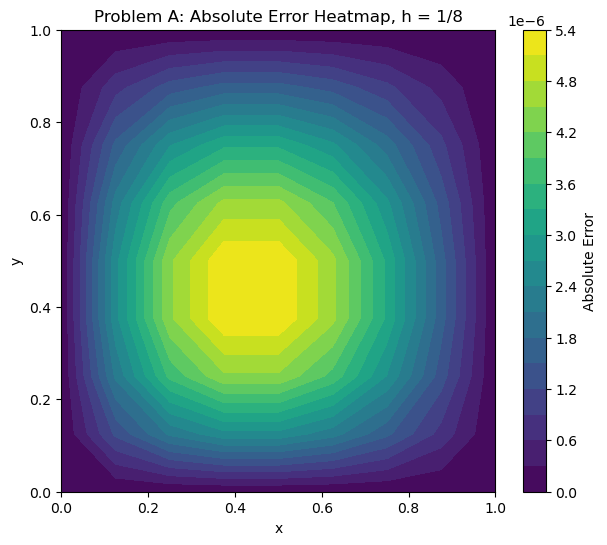

In [9]:
U_exact = np.zeros_like(U_num)

for i in range(len(x)):
    for j in range(len(y)):
        U_exact[i,j] = exact_laplace(x[i], y[j])

error = np.abs(U_exact - U_num)

plt.figure(figsize=(7,6))
plt.contourf(X, Y, error.T, levels=20)
plt.colorbar(label="Absolute Error")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Problem A: Absolute Error Heatmap, h = 1/8")
plt.show()

#### 3D Numerical Surface Plot (Gauss-Seidel)

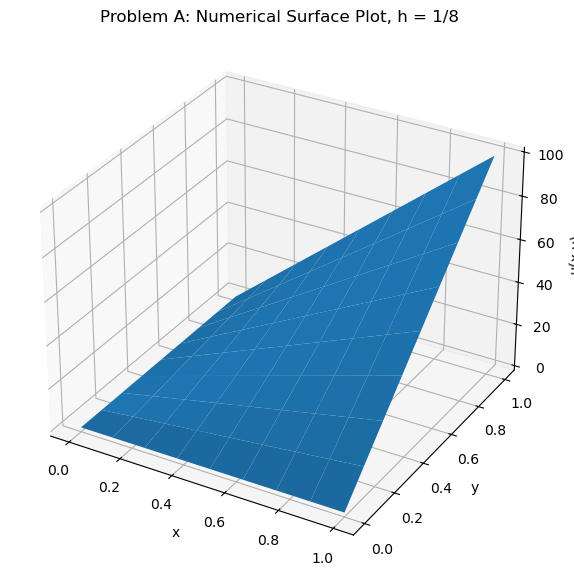

In [10]:
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, U_num.T)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u(x,y)")
ax.set_title("Problem A: Numerical Surface Plot, h = 1/8")

plt.show()

#### Gauss-Seidel vs SOR: Mesh Refinement

In [11]:
h_values = [1/4, 1/8, 1/16]

print(f"{'h':<10}{'GS Iterations':<18}{'SOR Iterations':<18}{'GS Max Error':<18}{'SOR Max Error':<18}")
print("-"*82)

for h in h_values:
    x_gs, y_gs, U_gs, iter_gs, change_gs = gauss_seidel_laplace(h)
    x_sor, y_sor, U_sor, iter_sor, change_sor = sor_laplace(h, omega=1.5)

    max_error_gs = 0
    max_error_sor = 0

    for i in range(len(x_gs)):
        for j in range(len(y_gs)):
            exact_value = exact_laplace(x_gs[i], y_gs[j])

            error_gs = abs(exact_value - U_gs[i,j])
            error_sor = abs(exact_value - U_sor[i,j])

            if error_gs > max_error_gs:
                max_error_gs = error_gs

            if error_sor > max_error_sor:
                max_error_sor = error_sor

    print(
        f"{h:<10.4f}"
        f"{iter_gs:<18}"
        f"{iter_sor:<18}"
        f"{max_error_gs:<18.6e}"
        f"{max_error_sor:<18.6e}"
    )

h         GS Iterations     SOR Iterations    GS Max Error      SOR Max Error     
----------------------------------------------------------------------------------
0.2500    27                28                5.122274e-07      2.630036e-07      
0.1250    102               32                5.367851e-06      1.399114e-07      
0.0625    373               128               2.487029e-05      7.193528e-06      


#### Discussion of Results

Evaluating the Laplace equation via Gauss-Seidel iteration and comparing against the exact solution, errors observed are generally around the order of $10^{-6}$, showing that the method of approximation is successful at completing a close discretization of the initial problem. The heat map produced of absolute errors demonstrates how the relatively minimal increases in maximum error occur in the center of the domain, and remained most accurate in regions where boundary conditions were defined, also observable in the heat map of numerical solutions.

In the mesh refinement study, a comparison was drawn between Gauss-Seidel and SOR; it can be observed that as mesh size was refined, G-S was forced to perform significantly more iterations, going from $27$ at $h=\frac{1}{4}$ to $373$ at $h=\frac{1}{16}$. While error slightly increased, remaining in a position of exceptional numerical accuracy, introducing more unknowns via mesh refinement brought higher computational cost. Comparatively, the SOR method performed similarly in accuracy, exhibiting a slower growth in maximum error, and also saw fewer necessary iterations, increasing only by four from $h=\frac{1}{4}$ to $h=\frac{1}{8}$. 

## Problem B: Parabolic PDE, Heat Equation

Heat Equation: $u_t = u_{xx}$, $0<x<1$, $t>0$,

Boundary conditions: $u(0,t) = u(1,t) = 0$,

Initial conditions: $u(x,0) = sin(\pi x)$.

Exact solution: $u(x,t) = e^{-\pi^2 t}sin(\pi x)$.

While elliptic PDEs like the one considered in problem A pertain to steady-state equilibrium systems, the heat equation here, an example of a parabolic PDE, is time-dependent. Thus we seek to investigate how numerical errors propagate and evolve as numerical solutions evolve through time, adding new factors of consideration like stability. 

In [12]:
def initial_heat(x):
    return np.sin(np.pi*x)

def exact_heat(x, t):
    return np.exp(-np.pi**2 * t) * np.sin(np.pi * x)

### Forward Difference Equation
$$w_{i}^{j+1} = w_{i}^{j}+\lambda(w_{i+1}^{j}-2w_{i}^{j}+w_{i-1}^{j}), \lambda \le \frac{1}{2}.$$

In [13]:
def fwd_diff_heat(h, k, T):
    n = int(1/h)
    m = int(T/k)
    x = np.linspace(0, 1, n+1)
    t = np.linspace(0, T, m+1)
    U = np.zeros((m+1, n+1))

    for i in range(n+1):
        U[0,i] = initial_heat(x[i])

    lam = k/h**2
    for j in range(m):
        for i in range(1,n):
            U[j+1, i] = U[j, i] + lam * (U[j, i+1] - 2*U[j, i] + U[j, i-1])
    return x, t, U, lam

### Stable Forward Difference
We use $h=0.1$, $k=0.004$.

This gives $\lambda = \frac{0.004}{0.1^2} = 0.4$.

#### Numerical Solutions & Error Table: Stable Forward Difference

In [23]:
h = 0.1
k = 0.004
T = 0.2

x_fd, t_fd, U_fd, lam_fd = fwd_diff_heat(h, k, T)

print("h =", h)
print("k =", k)
print("lambda =", lam_fd)
print("T =", T)
print()

print(f"{'x':<10}{'Exact':<15}{'Numerical':<15}{'Abs Error':<15}")
print("-"*55)

max_error = 0

for i in range(len(x_fd)):
    exact_value = exact_heat(x_fd[i], T)
    numerical_value = U_fd[-1, i]
    error = abs(exact_value - numerical_value)

    if error > max_error:
        max_error = error

    print(
        f"{x_fd[i]:<10.3f}"
        f"{exact_value:<15.6f}"
        f"{numerical_value:<15.6f}"
        f"{error:<15.6e}"
    )

print()
print("Maximum Error =", max_error)

h = 0.1
k = 0.004
lambda = 0.3999999999999999
T = 0.2

x         Exact          Numerical      Abs Error      
-------------------------------------------------------
0.000     0.000000       0.000000       0.000000e+00   
0.100     0.042926       0.041942       9.834403e-04   
0.200     0.081650       0.079779       1.870615e-03   
0.300     0.112381       0.109807       2.574680e-03   
0.400     0.132112       0.129086       3.026718e-03   
0.500     0.138911       0.135729       3.182480e-03   
0.600     0.132112       0.129086       3.026718e-03   
0.700     0.112381       0.109807       2.574680e-03   
0.800     0.081650       0.079779       1.870615e-03   
0.900     0.042926       0.041942       9.834403e-04   
1.000     0.000000       0.000000       1.701171e-17   

Maximum Error = 0.0031824796606316486


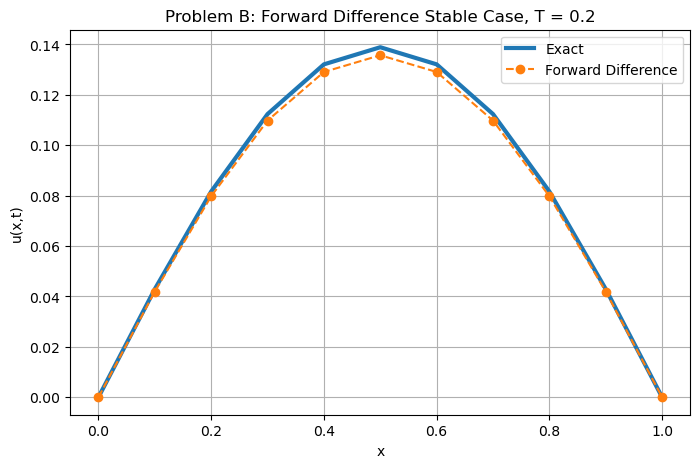

In [24]:
exact_values = np.zeros(len(x_fd))

for i in range(len(x_fd)):
    exact_values[i] = exact_heat(x_fd[i], T)

plt.figure(figsize=(8,5))
plt.plot(x_fd, exact_values, label="Exact", linewidth=3)
plt.plot(x_fd, U_fd[-1], "o--", label="Forward Difference")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Problem B: Forward Difference Stable Case, T = 0.2")
plt.legend()
plt.grid(True)
plt.show()

Now,
### Unstable Forward Difference

We use $h=0.1$, $k=0.006$, thus $\lambda = 0.6$,

satisfying $\lambda = \frac{k}{h^2} > \frac{1}{2}$.


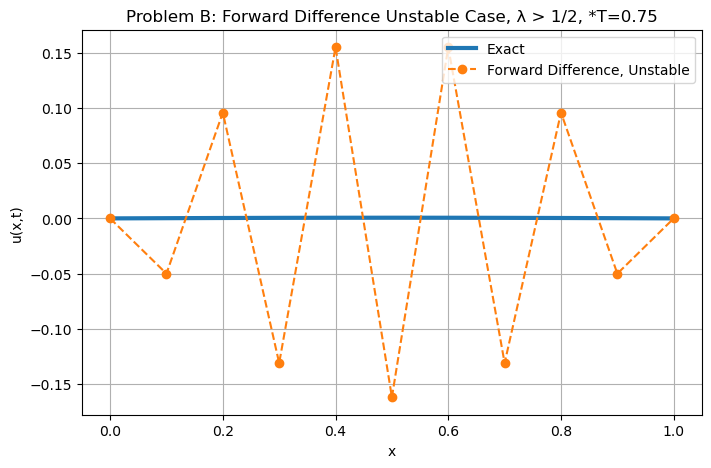

In [31]:
h = 0.1
k = 0.006
T = 0.75

x_un, t_un, U_un, lam_un = fwd_diff_heat(h, k, T)
exact_un = np.zeros(len(x_un))

for i in range(len(x_un)):
    exact_un[i] = exact_heat(x_un[i], T)

plt.figure(figsize=(8,5))
plt.plot(x_un, exact_un, label="Exact", linewidth=3)
plt.plot(x_un, U_un[-1], "o--", label="Forward Difference, Unstable")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Problem B: Forward Difference Unstable Case, λ > 1/2, *T=0.75")
plt.legend()
plt.grid(True)
plt.show()

#### Numerical Solutions & Error Table: Unstable Forward Difference

In [32]:
print("h =", h)
print("k =", k)
print("lambda =", lam_fd)
print("T =", T)
print()

print(f"{'x':<10}{'Exact':<15}{'Numerical':<15}{'Abs Error':<15}")
print("-"*55)

max_error = 0

for i in range(len(x_fd)):
    exact_value = exact_heat(x_fd[i], T)
    numerical_value = U_fd[-1, i]
    error = abs(exact_value - numerical_value)

    if error > max_error:
        max_error = error

    print(
        f"{x_fd[i]:<10.3f}"
        f"{exact_value:<15.6f}"
        f"{numerical_value:<15.6f}"
        f"{error:<15.6e}"
    )

print()
print("Maximum Error =", max_error)

h = 0.1
k = 0.006
lambda = 0.3999999999999999
T = 0.75

x         Exact          Numerical      Abs Error      
-------------------------------------------------------
0.000     0.000000       0.000000       0.000000e+00   
0.100     0.000188       0.041942       4.175399e-02   
0.200     0.000358       0.079779       7.942081e-02   
0.300     0.000493       0.109807       1.093134e-01   
0.400     0.000580       0.129086       1.285056e-01   
0.500     0.000610       0.135729       1.351187e-01   
0.600     0.000580       0.129086       1.285056e-01   
0.700     0.000493       0.109807       1.093134e-01   
0.800     0.000358       0.079779       7.942081e-02   
0.900     0.000188       0.041942       4.175399e-02   
1.000     0.000000       0.000000       7.469212e-20   

Maximum Error = 0.1351187460121623


In the stable Forward Difference case, for which we chose $\lambda = \frac{k}{h^2}$, the numerical solution remains smooth and follows closely the exact solution of the equation and exhibits the predictable behavior of heat flow. Satisfying the stability condition, the resulting numerical errors remain under control. In contrast, with the unstable Forward Difference method (which was changed to $T=0.75$ to demonstrate) exhibits large oscillations and comparatively large absolute errors. When the stability condition is not satisfied the solution demonstrates error amplification, accumulating rathering the dampening the minimal truncation errors that come with each progressive computation. 

### Backward Difference Method
$$-\lambda w_{i-1}^{j+1} + (1+2\lambda)w_{i}^{j+1} - \lambda w_{i+1}^{j+1} = w_{i}^{j}. $$

In [34]:
def bkwd_diff_heat(h, k, T):
    n = int(1 / h)
    m = int(T / k)
    x = np.linspace(0, 1, n + 1)
    t = np.linspace(0, T, m + 1)
    U = np.zeros((m + 1, n + 1))

    for i in range(n + 1):
        U[0, i] = initial_heat(x[i])

    lam = k / h**2

    A = np.zeros((n - 1, n - 1))

    for i in range(n - 1):
        A[i, i] = 1 + 2*lam
        
        if i > 0:
            A[i, i-1] = -lam
        if i < n - 2:
            A[i, i+1] = -lam

    for j in range(m):
        b = U[j, 1:n]
        solution = np.linalg.solve(A, b)
        U[j+1, 1:n] = solution

    return x, t, U, lam

### Crank-Nicolson Method
$$ -\frac{\lambda}{2}w_{i-1}^{j+1} + (1+\lambda)w_{i}^{j+1} - \frac{\lambda}{2}w_{i+1}^{j+1} = \frac{\lambda}{2}w_{i-1}^{j} + (1-\lambda)w_{i}^{j} + \frac{\lambda}{2}w_{i+1}^{j}.$$

In [35]:
def crank_nicolson_heat(h, k, T):
    n = int(1 / h)
    m = int(T / k)
    x = np.linspace(0, 1, n + 1)
    t = np.linspace(0, T, m + 1)
    U = np.zeros((m + 1, n + 1))

    for i in range(n + 1):
        U[0, i] = initial_heat(x[i])

    lam = k / h**2
    A = np.zeros((n - 1, n - 1))
    B = np.zeros((n - 1, n - 1))

    for i in range(n - 1):
        A[i, i] = 1 + lam
        B[i, i] = 1 - lam
        if i > 0:
            A[i, i-1] = -lam/2
            B[i, i-1] = lam/2
        if i < n - 2:
            A[i, i+1] = -lam/2
            B[i, i+1] = lam/2

    for j in range(m):
        b = B @ U[j, 1:n]
        solution = np.linalg.solve(A, b)
        U[j+1, 1:n] = solution

    return x, t, U, lam

#### Comparisons Between Heat Methods

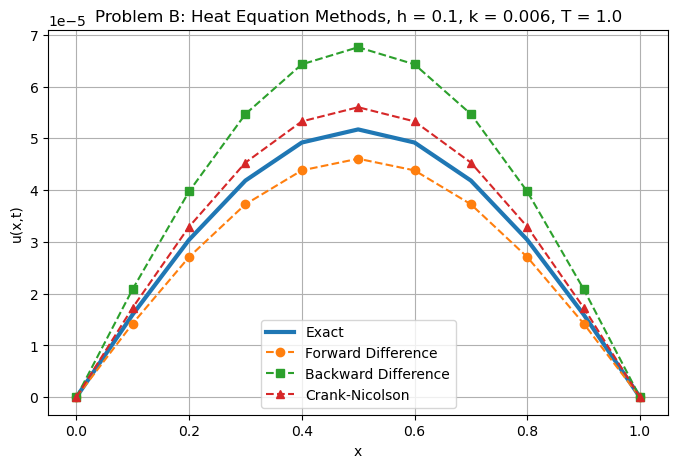

In [46]:
h = 0.1
k = 0.004
T = 1.0

x_fd, t_fd, U_fd, lam_fd = fwd_diff_heat(h, k, T)
x_bd, t_bd, U_bd, lam_bd = bkwd_diff_heat(h, k, T)
x_cn, t_cn, U_cn, lam_cn = crank_nicolson_heat(h, k, T)

exact_values = np.zeros(len(x_fd))

for i in range(len(x_fd)):
    exact_values[i] = exact_heat(x_fd[i], T)

plt.figure(figsize=(8,5))
plt.plot(x_fd, exact_values, label="Exact", linewidth=3)
plt.plot(x_fd, U_fd[-1], "o--", label="Forward Difference")
plt.plot(x_bd, U_bd[-1], "s--", label="Backward Difference")
plt.plot(x_cn, U_cn[-1], "^--", label="Crank-Nicolson")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Problem B: Heat Equation Methods, h = 0.1, k = 0.006, T = 1.0")
plt.legend()
plt.grid(True)
plt.show()

#### Maximum Error Table (Forward Diff, Backward Diff, Crank-Nicolson)

In [24]:
def max_error_heat(x, numerical, T):
    max_error = 0

    for i in range(len(x)):
        exact_value = exact_heat(x[i], T)
        error = abs(exact_value - numerical[i])

        if error > max_error:
            max_error = error

    return max_error

In [25]:
T = 0.2
h_values = [0.2, 0.1, 0.05]

print(f"{'Method':<20}{'h=0.2':<15}{'h=0.1':<15}{'h=0.05':<15}")
print("-"*65)

methods = [("Forward", fwd_diff_heat),
    ("Backward", bkwd_diff_heat),
    ("Crank-Nicolson", crank_nicolson_heat)]

for method_name, method in methods:

    row = f"{method_name:<20}"

    for h in h_values:
        if h == 0.2:
            k = 0.01      
        elif h == 0.1:
            k = 0.0025   
        else:
            k = 0.000625 
        x, t, U, lam = method(h, k, T)
        error = max_error_heat(x, U[-1], T)
        row += f"{error:<15.6e}"

    print(row)

Method              h=0.2          h=0.1          h=0.05         
-----------------------------------------------------------------
Forward             4.333379e-03   1.130451e-03   2.820779e-04   
Backward            2.135857e-02   5.633278e-03   1.409226e-03   
Crank-Nicolson      8.539864e-03   2.252286e-03   5.636130e-04   


#### Discussion of Results

Assuming the stability condition for the Forward Difference is satisfied, each of the three methods produce highly accurate approximations. Forward Difference and Crank-Nicolson observed similarly low maximum errors; despite the higher computational cost of Crank-Nicolson it does not have to adhere to the same stability conditions and thus may generally be a more accurate finite-difference method in the context of diffusion problems like this one. The Backward Difference method has this advantage as well but exhibits the largest maximum error, as demonstrated in the plot and table. 

# Problem C: Additional Numerical Experiments

## Experiment #1: Mesh Refinement, Crank-Nicholson

With experiment #1 the study regarding the finite-difference methods previously discussed will be expanded upon. The object of this experiment is to investigate the effect of mesh refinement on the accuracy of the aforementioned Crank-Nicholson method for the heat equation. The assumption before testing is that refinement of the computational mesh would improve numerical approximation and demonstrate convergence towards the exact solution.

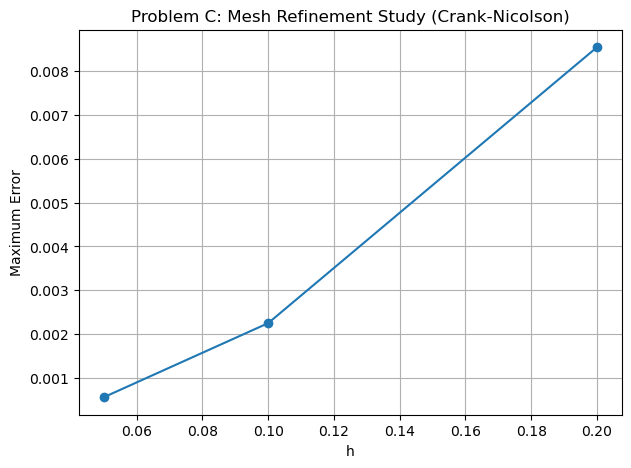

In [26]:
h_values = [0.2, 0.1, 0.05]

errors_cn = []

for h in h_values:

    if h == 0.2:
        k = 0.01
    elif h == 0.1:
        k = 0.0025
    else:
        k = 0.000625

    x, t, U, lam = crank_nicolson_heat(h, k, 0.2)

    errors_cn.append(
        max_error_heat(x, U[-1], 0.2)
    )

plt.figure(figsize=(7,5))
plt.plot(h_values, errors_cn, "o-")
plt.xlabel("h")
plt.ylabel("Maximum Error")
plt.title("Problem C: Mesh Refinement Study (Crank-Nicolson)")
plt.grid(True)
plt.show()

In [28]:
h_values = [0.2, 0.1, 0.05, 0.025]
T = 0.2

errors = []

print(f"{'h':<10}{'k':<12}{'lambda':<12}{'Max Error':<18}{'Error Ratio':<15}")
print("-"*70)

previous_error = None

for h in h_values:
    k = 0.25 * h**2
    
    x, t, U, lam = crank_nicolson_heat(h, k, T)
    error = max_error_heat(x, U[-1], T)
    errors.append(error)
    
    if previous_error is None:
        ratio_text = "---"
    else:
        ratio_text = f"{previous_error/error:.3f}"
    
    print(
        f"{h:<10.4f}"
        f"{k:<12.6f}"
        f"{lam:<12.4f}"
        f"{error:<18.6e}"
        f"{ratio_text:<15}"
    )
    
    previous_error = error

h         k           lambda      Max Error         Error Ratio    
----------------------------------------------------------------------
0.2000    0.010000    0.2500      2.264438e-02      ---            
0.1000    0.002500    0.2500      5.749593e-03      3.938          
0.0500    0.000625    0.2500      1.424847e-03      4.035          
0.0250    0.000156    0.2500      3.554292e-04      4.009          


## Experiment #2: Stability Threshold, Forward Difference Method

As previously demonstrated, the Forward Difference Method is conditionally stable dependent on the parameter $\lambda=\frac{k}{h^2}$ satisfying $\lambda \le \frac{1}{2}$. This experiment seeks to investigate how the numerical solution responds when exceeding the stability threshold, testing at values of $\lambda$ below, equal to, and above the critical value. 

Problem C Experiment 2: Forward Difference Stability Study

lambda      k           Stable?     Max Error         Max |Numerical|   
---------------------------------------------------------------------------
0.25        0.00250     Yes         8.250596e-07      5.089813e-05      
0.40        0.00400     Yes         3.782497e-06      4.794069e-05      
0.50        0.00500     Yes         5.691299e-06      4.603189e-05      
0.55        0.00550     No          7.955579e-06      4.376761e-05      
0.60        0.00600     No          4.896686e+04      4.896686e+04      


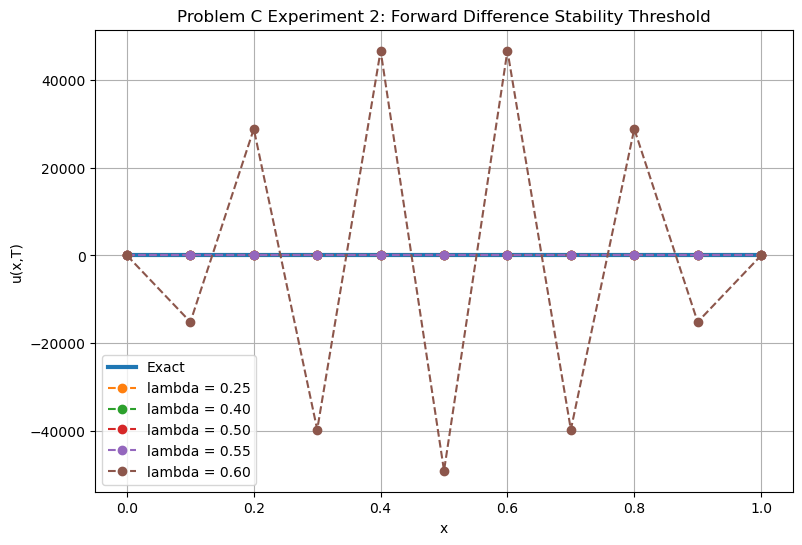

In [34]:
h = 0.1
T = 1.0

lambda_values = [0.25, 0.40, 0.50, 0.55, 0.60]

plt.figure(figsize=(9,6))

# Exact solution curve
x_exact = np.linspace(0, 1, 100)
u_exact = np.zeros(len(x_exact))

for i in range(len(x_exact)):
    u_exact[i] = exact_heat(x_exact[i], T)

plt.plot(x_exact, u_exact, label="Exact", linewidth=3)

print("Problem C Experiment 2: Forward Difference Stability Study")
print()
print(f"{'lambda':<12}{'k':<12}{'Stable?':<12}{'Max Error':<18}{'Max |Numerical|':<18}")
print("-"*75)

for lam in lambda_values:
    k = lam * h**2
    
    x, t, U, actual_lam = fwd_diff_heat(h, k, T)
    
    max_error = max_error_heat(x, U[-1], T)
    max_abs_value = np.max(np.abs(U[-1]))
    
    if actual_lam <= 0.5:
        stable_text = "Yes"
    else:
        stable_text = "No"
    
    print(
        f"{actual_lam:<12.2f}"
        f"{k:<12.5f}"
        f"{stable_text:<12}"
        f"{max_error:<18.6e}"
        f"{max_abs_value:<18.6e}"
    )
    
    plt.plot(x, U[-1], "o--", label=f"lambda = {actual_lam:.2f}")

plt.xlabel("x")
plt.ylabel("u(x,T)")
plt.title("Problem C Experiment 2: Forward Difference Stability Threshold")
plt.legend()
plt.grid(True)
plt.show()

#### Discussion of Results

With experiment #1 we observe how mesh point refinement affects the accuracy of the Crank-Nicolson method previously established. The theoretical assumption is that reducing mesh spacing improves the accuracy of numerical approximations; the results demonstrated were consistent with that prediction. The plot shows the maximum error growing by about a factor of four with the doubling of the mesh spacing. 

In experiment #2, the stability threshold of the Forward Difference method is rehashed and observed for compliance with theoretical assumptions about stability in a practical application. In the plot once can see the values of $\lambda$ even very close to the stability boundary still produce meaningful solutions/visually consistent behavior. For $\lambda = 0.60$ there is an obviously dramatic divergence in behavior; despite the finite-different approximation remaining the same the solution exhibits large oscillations. 

## Conclusion

In this project investigations were made into the performance of various finite-difference methods for both elliptic and parabolic partial differential equations. Studies on mesh refinement and stability further expand on the performance capabilities of the respective methods and what is at the root of accuracy and convergence in numerical approximation.

For the elliptic problem it was observed how the Gauss-Seidel and SOR iterative methods can come to similarly accurately approximations of the exact solution for the Laplace problem, while differing in algorithmic efficiency, an important consideration when doing large-scale computations. Tradeoffs with computational refinement are also demonstrated with the mesh refinement study in Experiment #1, which showed consistent decrease in maximum error with the reduction of mesh spacing. With the parabolic heat equation, specifically in the case of the Forward Difference method, it was observed how consistency in the approximation of the underlying differential equation is not the sole factor in guaranteeing convergence; violation of the stability condition caused large oscillations and catastrophic error propagation observable at T=0.75. Both consistency and stability are necessary considerations in producing accurate approximations in various conditions. 

